Imports

In [1]:
import torch
import torchvision
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.io import read_image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import os
from datetime import datetime
from monai.networks.schedulers import DDIMScheduler
from PIL import Image
import pandas as pd
import nrrd
import numpy as np


import torchvision.utils as vutils


device = torch.device("cuda:1")
print(f"Using device: {device}")

The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling t

Using device: cuda:1


Custom Dataset Class

In [2]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = [item for item in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir,item))]
        self.image_paths = []
        self.labels = []
        
        # Collect image file paths and corresponding labels
        for label in self.classes:
            class_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_name))
                self.labels.append(self.classes.index(label))  # Assign numeric labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")  # Load the image
        # image = image.float() / 255.0

        if self.transform:
            image = self.transform(image)

        label = int(self.labels[idx])       # Get the label
        

        
        return image, label

In [3]:
class DatasetFromDataFrame(Dataset):
    def __init__(self, root_dir, dataframe, transform=None):
        self.root_dir = root_dir
        self.df = dataframe
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for i in range(df.shape[0]):
            img_name = df.iloc[i,0]
            self.image_paths.append(os.path.join(self.root_dir,img_name))
            self.labels.append(0)
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        data, header = nrrd.read(img_path)
        data = np.squeeze(data)
        normalized = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-5)
        scaled_data = (normalized * 255)
        scaled_data = scaled_data[0].astype(np.uint8)
        image = Image.fromarray(scaled_data).convert('RGB')
        image = image.rotate(270)
    

        if self.transform:
            image = self.transform(image)
        
        label = int(self.labels[idx])

        return image, label

Transform

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor(),           # Convert images to PyTorch tensors
])

Dataset

(-0.5, 1041.5, 131.5, -0.5)

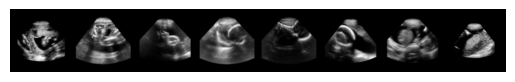

In [5]:
# Specify the path to your dataset
root_val_dir = '/mnt/raid/home/ajarry/data/trainer'
train_dir = os.path.join(root_val_dir,"temp_train/")
root_dir_train = '/mnt/raid/C1_ML_Analysis'


parquet = "/mnt/raid/C1_ML_Analysis/CSV_files/extract_frames_Dataset_C_masked_resampled_256_spc075_wscores_meta_noflyto_1e-4.parquet"
df = pd.read_parquet(parquet, engine="pyarrow")
# Create dataset instance
# custom_dataset = CustomImageDataset(root_dir=root_dir, transform=transform)
val_dataset = CustomImageDataset(root_dir=train_dir,transform=transform)
train_dataset = DatasetFromDataFrame(root_dir=root_dir_train,dataframe=df,transform=transform)

# View some examples
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
x, y = next(iter(train_dataloader))

plt.imshow(torchvision.utils.make_grid(x)[0], cmap='gray')
plt.axis('off')

Corruption Method

In [6]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1,1,1,1)  # Sort shape so broadcasting works
    return x * (1 - amount) + noise * amount

torch.Size([8, 3, 128, 128])


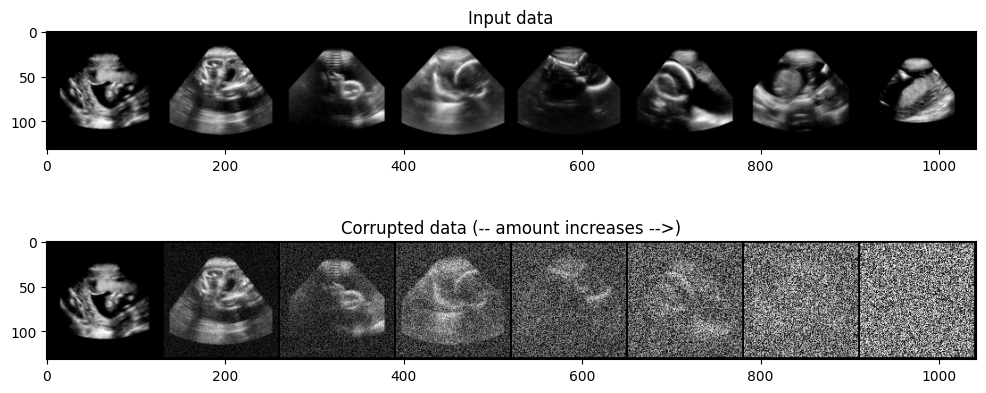

In [7]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="gray")

# Adding noise
amount = torch.linspace(0, 1, x.shape[0])  # Lft to right -> more corruption
noised_x = corrupt(x, amount)

print(x.shape)
# Plotting the noised version
axs[1].set_title("Corrupted data (-- amount increases -->)")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap="gray")

Basic UNET Model

In [8]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation."""

    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 128, kernel_size=5, padding=2),
                nn.Conv2d(128, 128, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(128, 128, kernel_size=5, padding=2),
                nn.Conv2d(128, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.ReLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 4:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection
                x = self.downscale(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.up_layers):
            if i > 0:  # For all except the first up layer
                x = self.upscale(x)  # Upscale
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x

Training

Finished epoch 0. Average loss for this epoch: 0.735400. Average validation loss: 0.000000


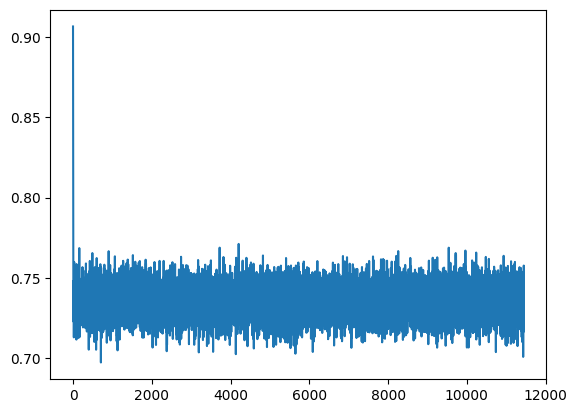

In [22]:
# Dataloader (you can mess with batch size)
batch_size = 64
num_workers = 4
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)

# How many runs through the data should we do?
n_epochs = 1

# Create the network
net = BasicUNet()
net.to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-4)

# Keeping a record of the losses for later viewing
train_losses = []
val_losses = []

# Define directory for saving checkpoints
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"outputs/output_{timestamp}/"
os.makedirs(output_dir, exist_ok=True)

# The training loop
for epoch in range(n_epochs):

    net.train()
    
    for x, y in train_dataloader:
        # Get some data and prepare the corrupted version
        x = x.to(device)  # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device)  # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount)  # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x)

        # Calculate the loss
        train_loss = loss_fn(pred, x)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        train_loss.backward()
        opt.step()

        # Store the loss for later
        train_losses.append(train_loss.item())

    # Validation phase
    net.eval()
    with torch.no_grad():
        for x, y in val_dataloader:
            x = x.to(device)
            outputs = net(x)
            val_loss = loss_fn(outputs,x)
            

    # Print our the average of the loss values for this epoch:
    avg_train_loss = sum(train_losses[-len(train_dataloader) :]) / len(train_dataloader)
    avg_val_loss = sum(val_losses) / len(val_dataloader)
    print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_train_loss:05f}. Average validation loss: {avg_val_loss:05f}")

    checkpoint_filename = f"checkpoint_epoch_{epoch+1}.pth"
    checkpoint_path = os.path.join(output_dir, checkpoint_filename)

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        }
    torch.save(checkpoint, checkpoint_path)

# View the loss curve
plt.plot(train_losses)
final_model_path = os.path.join(output_dir, "model.pth")
torch.save(net.state_dict(), final_model_path)


First Results

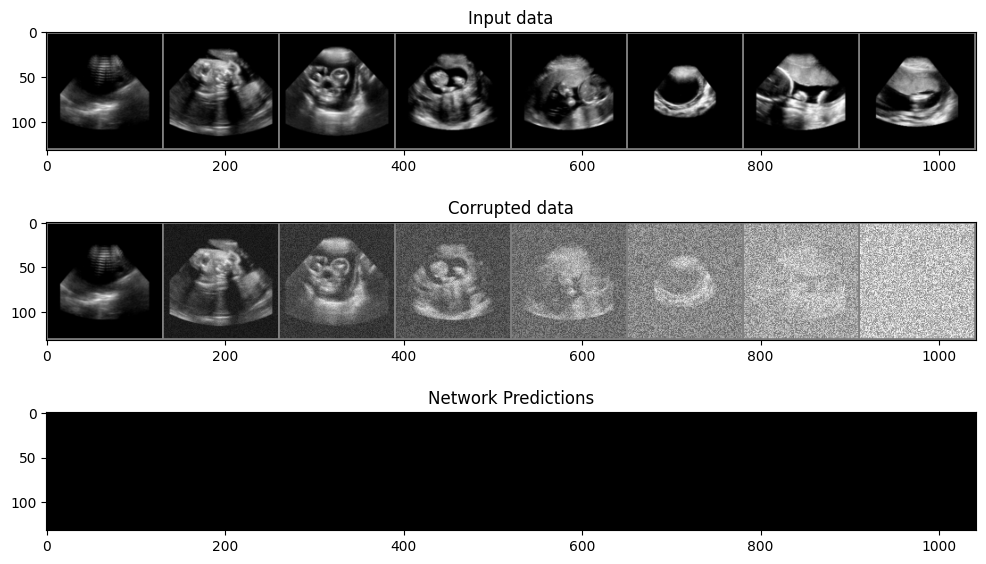

In [23]:
# @markdown Visualizing model predictions on noisy inputs:

# Fetch some data
x, y = next(iter(train_dataloader))
x = x[:8]  # Only using the first 8 for easy plotting

# Corrupt with a range of amounts
amount = torch.linspace(0, 1, x.shape[0])  # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Get the model predictions
with torch.no_grad():
    preds = net(noised_x.to(device)).detach().cpu()

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="gray")
axs[1].set_title("Corrupted data")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap="gray")
axs[2].set_title("Network Predictions")
axs[2].imshow(torchvision.utils.make_grid(preds)[0], cmap="gray")

Sampling

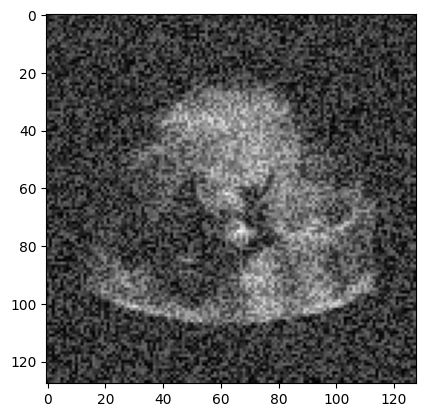

In [24]:
noisy_ultra = noised_x[4][0]
plt.imshow(noisy_ultra,cmap="gray")


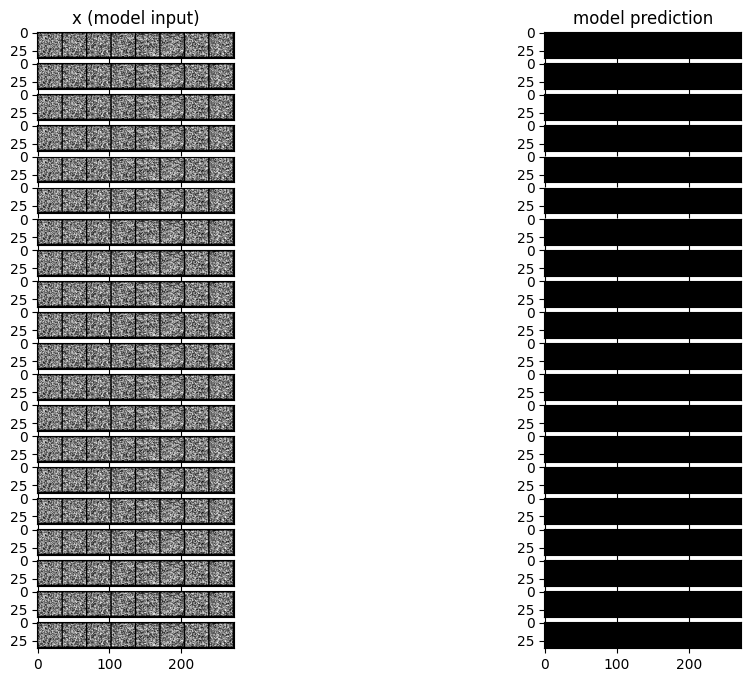

In [25]:
# @markdown Sampling strategy: Break the process into 5 steps and move 1/5'th of the way there each time:
n_steps = 20
x = torch.rand(8, 3, 32,32).to(device)  # Start from random
step_history = [x.detach().cpu()]
pred_output_history = []

for i in range(n_steps):
    with torch.no_grad():  # No need to track gradients during inference
        pred = net(x)  # Predict the denoised x0
    pred_output_history.append(pred.detach().cpu())  # Store model output for plotting
    mix_factor = 1 / (n_steps - i)  # How much we move towards the prediction
    x = x * (1 - mix_factor) + pred * mix_factor  # Move part of the way there
    step_history.append(x.detach().cpu())  # Store step for plotting

fig, axs = plt.subplots(n_steps, 2, figsize=(12, 8), sharex=True)
axs[0, 0].set_title("x (model input)")
axs[0, 1].set_title("model prediction")
for i in range(n_steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_history[i])[0].clip(0, 1), cmap="gray")
    axs[i, 1].imshow(torchvision.utils.make_grid(pred_output_history[i])[0].clip(0, 1), cmap="gray")

In [26]:

num_inference_steps = 1000
scheduler.set_timesteps(num_inference_steps)

initial_noise = torch.randn(1, 3, 128,128)  # Adjust shape as needed
x_t = initial_noise  # Start with random noise


x_t = x_t.to(device)
net = net.to(device)

for t in scheduler.timesteps:
    with torch.no_grad():
        # Get the model's prediction of noise at this step
        model_output = net(x_t)  # Adjust for model's input format if needed
        # Update x_t to the denoised image for this timestep
        x_t = scheduler.step(model_output, t, x_t)[0]

# Normalize and move to CPU
x_t = x_t.detach().cpu()  # Ensure it's on the CPU and detached from computation graph
# x_t = (x_t + 1) / 2  # Normalize to range [0, 1]
# x_t = torch.clamp(x_t, 0, 1)  # Ensure all values are in the range [0, 1]
x_t = x_t.squeeze(0)  # Add batch dimension if not present
print(x_t.shape)

# Display the image
plt.imshow(x_t[0],cmap="gray")
plt.axis("off")  # Hide axes for cleaner display
plt.show()



NameError: name 'scheduler' is not defined

: 